# 1. Import and Install Dependencies

## 1.1 Install Dependencies

In [1]:
%pip install tensorflow==2.15.0 matplotlib librosa

Note: you may need to restart the kernel to use updated packages.


## 1.2 Load Dependencies

In [4]:
import os
from matplotlib import pyplot as plt
import tensorflow as tf
import librosa as lr
import numpy as np

# 2. Build Data Loading Function

## 2.1 Define Paths to Files

In [7]:
CRY_FILE = os.path.join('data', 'cry', '1c.wav')
NOT_CRY_FILE = os.path.join('data', 'not_cry', '110n.wav')

In [8]:
CRY_FILE

'data\\cry\\1c.wav'

## 2.2 Build Dataloading Function

In [9]:
def load_wav_16k_mono(filename):
    if isinstance(filename, tf.Tensor):
        filename = filename.numpy().decode("utf-8") #convert tensor to a python string
    # Load audio with librosa to handle .ogg and .wav, handles the file, sets sr to 16000 Hz, and makes audio mono for consistency
    audio, sr = lr.load(filename, sr = 16000, mono = True)

    #return NumPy array
    return audio.astype(np.float32)

## 2.3 Plot Wave

In [10]:
wave = load_wav_16k_mono(CRY_FILE)
nwave = load_wav_16k_mono(NOT_CRY_FILE)

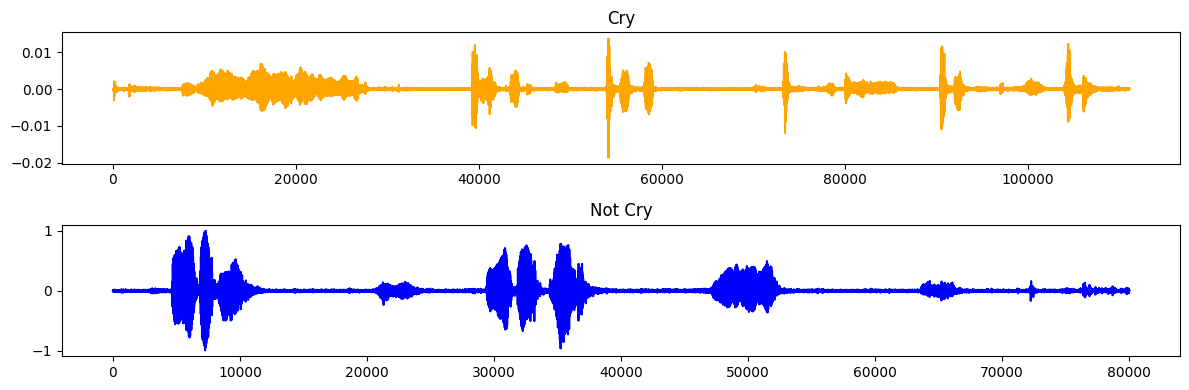

In [13]:
plt.figure(figsize=(12, 4))

plt.subplot(2, 1, 1)
plt.title("Cry")
plt.plot(wave, color='orange')

plt.subplot(2, 1, 2)
plt.title("Not Cry")
plt.plot(nwave, color='blue')

plt.tight_layout()
plt.show()


# 3. Create Tensorflow Dataset

## 3.1 Define Paths to Positive and Negative Data

In [14]:
POS = os.path.join('data', 'cry')
NEG = os.path.join('data', 'not_cry')

## 3.2 Create Tensorflow Datasets

In [15]:
pos = tf.data.Dataset.list_files(POS+'\*')
neg = tf.data.Dataset.list_files(NEG+'\*')

In [16]:
pos.as_numpy_iterator().next()
tf.ones(len(pos))
tf.zeros(len(neg))

<tf.Tensor: shape=(324,), dtype=float32, numpy=
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

## 3.3 Add labels and Combine Positive and Negative Samples

In [17]:
positives = tf.data.Dataset.zip((pos, tf.data.Dataset.from_tensor_slices(tf.ones(len(pos)))))
negatives = tf.data.Dataset.zip((neg, tf.data.Dataset.from_tensor_slices(tf.zeros(len(neg)))))
data = positives.concatenate(negatives)

In [18]:
data.shuffle(10000).as_numpy_iterator().next()

(b'data\\not_cry\\57n.ogg', 0.0)

# 4. Determine Average Length of a Baby Crying

## 4.1 Calculate Wave Cycle Length

In [19]:
lengths = []
for file in os.listdir(os.path.join('data', 'cry')):
    tensor_wave = load_wav_16k_mono(os.path.join('data', 'cry', file))
    lengths.append(len(tensor_wave))

In [20]:
os.listdir(os.path.join('data', 'cry'))
lengths

[107840,
 108160,
 107840,
 107840,
 108160,
 111040,
 108480,
 110400,
 112000,
 111360,
 104320,
 110400,
 112000,
 112000,
 109760,
 112000,
 112000,
 112000,
 112000,
 112000,
 109760,
 111360,
 110720,
 110720,
 110720,
 110720,
 110720,
 109440,
 109760,
 112960,
 112960,
 112960,
 112000,
 106560,
 80016,
 80016,
 80016,
 80016,
 80016,
 80016,
 80016,
 80016,
 112960,
 112000,
 112960,
 112960,
 112960,
 112960,
 112960,
 112960,
 112640,
 112960,
 112960,
 112960,
 112000,
 111040,
 110400,
 112000,
 112000,
 112000,
 112000,
 108480,
 108480,
 108480,
 108480,
 112000,
 108480,
 108480,
 80016,
 80016,
 80016,
 80016,
 80016,
 80016,
 80016,
 80016,
 112000,
 112000,
 112000,
 112000,
 112000,
 110400,
 110720,
 112000,
 112000,
 109760,
 110080,
 112000,
 109760,
 109760,
 109760,
 109760,
 112000,
 112000,
 112000,
 112000,
 112000,
 112000,
 112000,
 112000,
 106560,
 106880,
 111360,
 105920,
 110720,
 110720,
 109760,
 110720,
 112000,
 112000,
 111040,
 112000,
 112000,

## 4.2 Calculate Mean, Min and Max

In [21]:
tf.math.reduce_mean(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=104826>

In [16]:
104826/16000

6.551625

In [22]:
tf.math.reduce_min(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=79413>

In [18]:
79413/16000

4.9633125

In [19]:
tf.math.reduce_max(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=112960>

In [20]:
112960/16000

7.06

# 5. Build Preprocessing Function to Convert to Spectrogram

## 5.1 Build Preprocessing Function

In [23]:
#wrapper function for librosa, needs file paths as tensors
def load_audio_tf(path):
    #calls python function to load audio on a tensor and return a NumPy array which then gets converted to a tensor
    audio = tf.py_function(load_wav_16k_mono, [path], tf.float32)
    #set 1D
    audio.set_shape([None])
    return audio

def preprocess(file_path, label): 
    #returns the 1D float32 tensor
    wav = load_audio_tf(file_path)

    #normalize fix for bad spectrograms, helps make the amplitude consistent
    wav = wav / (tf.reduce_max(tf.abs(wav)) + 1e-6)

    #trim to 6 seconds
    wav = wav[:96000]

    #padding for shorter clips
    zero_padding = tf.zeros([96000] - tf.shape(wav), dtype=tf.float32)
    wav = tf.concat([zero_padding, wav],0)

    #converts waveform into 20ms windows with 2ms hop
    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)

    #drop phase and keep magnitude
    spectrogram = tf.abs(spectrogram)

    #log scaling helps noise become visible in the spectrograms especially the quiet clips
    spectrogram = tf.math.log(spectrogram + 1e-6)

    #channel dimension for CNN (convolutional neural network)
    spectrogram = tf.expand_dims(spectrogram, axis=2)
    
    return spectrogram, label

In [24]:
wav = load_wav_16k_mono(CRY_FILE)
wav = wav[:96000]
zero_padding = tf.zeros([96000] - tf.shape(wav), dtype=tf.float32)
wav = tf.concat([zero_padding, wav],0)

In [25]:
spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
spectrogram = tf.expand_dims(spectrogram, axis=2)
spectrogram

<tf.Tensor: shape=(2991, 257, 1), dtype=complex64, numpy=
array([[[-3.3238991e-03+0.0000000e+00j],
        [ 9.3326438e-03-3.1614201e-03j],
        [-2.4372881e-02-8.1777330e-03j],
        ...,
        [ 1.8626451e-09+1.3969839e-09j],
        [-4.6566129e-10-2.4447218e-09j],
        [-4.6566129e-10+0.0000000e+00j]],

       [[-1.8905931e-03+0.0000000e+00j],
        [ 6.1947014e-03+7.2897309e-03j],
        [ 2.3367675e-03-3.0719755e-02j],
        ...,
        [ 1.3969839e-09-1.8626451e-09j],
        [-2.3283064e-09-1.8626451e-09j],
        [ 1.3969839e-09+0.0000000e+00j]],

       [[ 3.3318480e-03+0.0000000e+00j],
        [-7.6181088e-03+1.0218725e-02j],
        [ 3.6180031e-02-8.3181942e-03j],
        ...,
        [ 0.0000000e+00-2.7939677e-09j],
        [ 2.3283064e-10+1.3969839e-09j],
        [-1.8626451e-09+0.0000000e+00j]],

       ...,

       [[ 1.4953138e-03+0.0000000e+00j],
        [ 6.7059929e-04-2.2798898e-03j],
        [-2.7294809e-03+7.4113748e-05j],
        ...,
        [ 

## 5.2 Test Out the Function and Viz the Spectrogram

In [26]:
filepath, label = positives.shuffle(buffer_size=10000).as_numpy_iterator().next()

In [27]:
spectrogram, label = preprocess(filepath, label)

In [28]:
spectrogram

<tf.Tensor: shape=(2991, 257, 1), dtype=float32, numpy=
array([[[ -7.6185174],
        [ -7.617226 ],
        [ -7.614759 ],
        ...,
        [-13.815327 ],
        [-13.815365 ],
        [-13.815394 ]],

       [[ -8.423777 ],
        [ -8.424371 ],
        [ -8.426155 ],
        ...,
        [-13.815511 ],
        [-13.8155   ],
        [-13.815496 ]],

       [[-10.219913 ],
        [-10.220462 ],
        [-10.22211  ],
        ...,
        [-13.815482 ],
        [-13.815489 ],
        [-13.815476 ]],

       ...,

       [[ -5.4839125],
        [ -5.1651597],
        [ -4.341736 ],
        ...,
        [-13.805999 ],
        [-13.806169 ],
        [-13.811792 ]],

       [[ -9.268497 ],
        [ -6.160587 ],
        [ -4.7743344],
        ...,
        [-13.81009  ],
        [-13.812978 ],
        [-13.806644 ]],

       [[ -6.1864877],
        [ -6.7575035],
        [ -4.858308 ],
        ...,
        [-13.812015 ],
        [-13.810836 ],
        [-13.81272  ]]], dtype=float32

In [29]:
pos_wav = load_wav_16k_mono(CRY_FILE)
neg_wav = load_wav_16k_mono(NOT_CRY_FILE)

print("pos max:", np.max(np.abs(pos_wav)))
print("neg max:", np.max(np.abs(neg_wav)))
print("pos mean:", np.mean(np.abs(pos_wav)))
print("neg mean:", np.mean(np.abs(neg_wav)))




pos max: 0.018711355
neg max: 1.0003061
pos mean: 0.0004965944
neg mean: 0.050369304


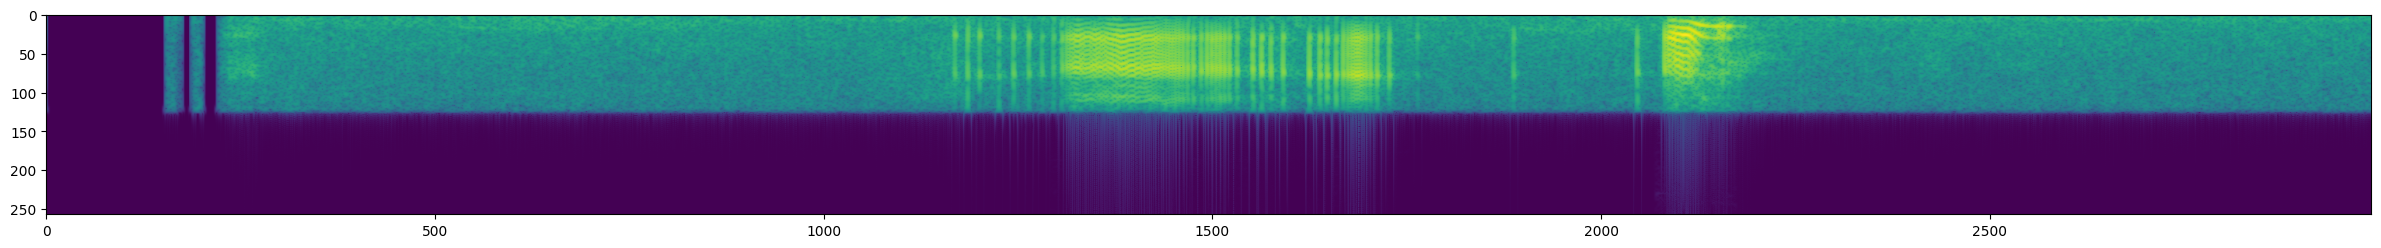

In [33]:
plt.figure(figsize=(30,20))
plt.imshow(tf.transpose(spectrogram)[0])
plt.show()

# 6. Create Training and Testing Partitions

## 6.1 Create a Tensorflow Data Pipeline

In [34]:
data = data.map(preprocess)
data = data.cache()
data = data.shuffle(buffer_size=1000)
data = data.batch(16)
data = data.prefetch(8)

## 6.2 Split into Training and Testing Partitions

In [36]:
len(data)*.7

39.199999999999996

In [37]:
train = data.take(33)
test = data.skip(33).take(15)

## 6.3 Test One Batch

In [38]:
samples, labels = train.as_numpy_iterator().next()

In [39]:
samples.shape

(16, 2991, 257, 1)

# 7. Build Deep Learning Model

## 7.1 Load Tensorflow Dependencies

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D, GlobalAveragePooling2D

## 7.2 Build Sequential Model, Compile and View Summary

In [41]:
model = Sequential()
model.add(Conv2D(16, (3,3), activation='relu', input_shape=(2991, 257,1)))
model.add(Conv2D(16, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(GlobalAveragePooling2D())
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [42]:
model.compile('Adam', loss='BinaryCrossentropy', metrics=[tf.keras.metrics.Recall(),tf.keras.metrics.Precision()])

In [43]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 2989, 255, 16)     160       
                                                                 
 conv2d_1 (Conv2D)           (None, 2987, 253, 16)     2320      
                                                                 
 max_pooling2d (MaxPooling2  (None, 1493, 126, 16)     0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 1491, 124, 32)     4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 745, 62, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 743, 60, 64)       1

## 7.3 Fit Model, View Loss and KPI Plots

In [57]:
hist = model.fit(train, epochs=15, validation_data=test)

Epoch 1/15
33/33 [==============================] - 66s 2s/step - loss: 0.1173 - recall: 0.9910 - precision: 0.9594 - val_loss: 0.1016 - val_recall: 0.9866 - val_precision: 0.9484
Epoch 2/15
33/33 [==============================] - 64s 2s/step - loss: 0.0953 - recall: 0.9885 - precision: 0.9637 - val_loss: 0.0735 - val_recall: 0.9937 - val_precision: 0.9814
Epoch 3/15
33/33 [==============================] - 63s 2s/step - loss: 0.1549 - recall: 0.9821 - precision: 0.9400 - val_loss: 0.1213 - val_recall: 0.9939 - val_precision: 0.9647
Epoch 4/15
33/33 [==============================] - 62s 2s/step - loss: 0.1166 - recall: 0.9941 - precision: 0.9599 - val_loss: 0.0989 - val_recall: 0.9937 - val_precision: 0.9814
Epoch 5/15
33/33 [==============================] - 62s 2s/step - loss: 0.1110 - recall: 0.9970 - precision: 0.9538 - val_loss: 0.1798 - val_recall: 0.9141 - val_precision: 0.9739
Epoch 6/15
33/33 [==============================] - 63s 2s/step - loss: 0.1158 - recall: 0.9824 - pr

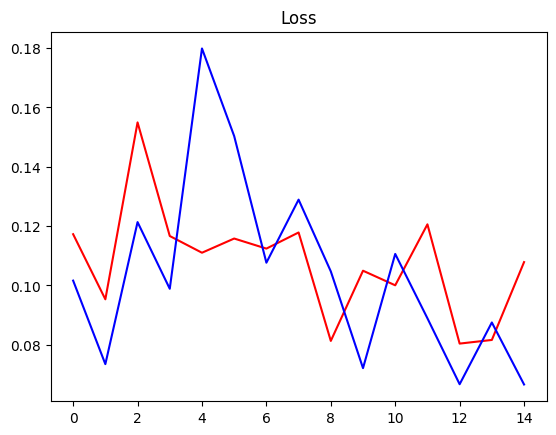

In [58]:
plt.title('Loss')
plt.plot(hist.history['loss'], 'r')
plt.plot(hist.history['val_loss'], 'b')
plt.show()

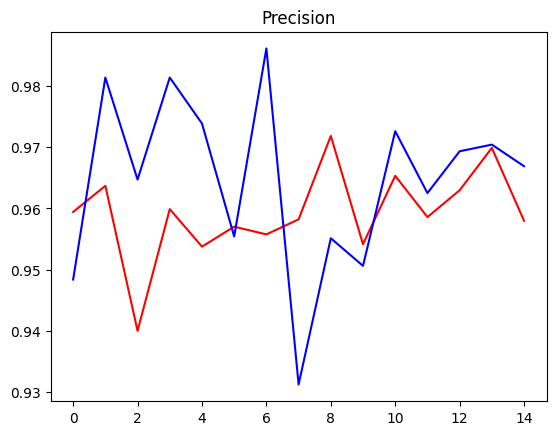

In [59]:
plt.title('Precision')
plt.plot(hist.history['precision'], 'r')
plt.plot(hist.history['val_precision'], 'b')
plt.show()

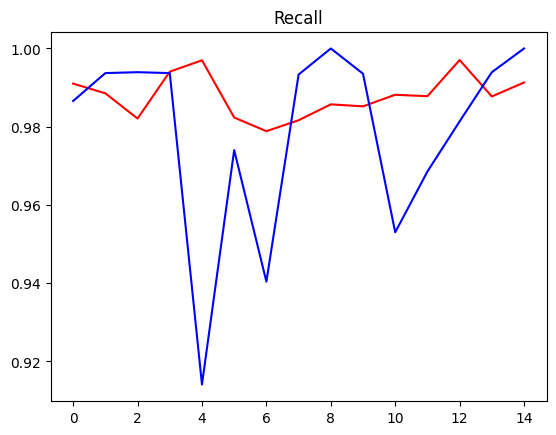

In [60]:
plt.title('Recall')
plt.plot(hist.history['recall'], 'r')
plt.plot(hist.history['val_recall'], 'b')
plt.show()

In [61]:
model.save("cry_detector.h5")

c:\Users\Ethan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [62]:
import tensorflow as tf

#Load trained keras model
model = tf.keras.models.load_model("cry_detector.h5")

#Create the converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

#Convert the model
tflite_model = converter.convert()

#Save the TFLite model
with open("cry_detector.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\Ethan\AppData\Local\Temp\tmpig4vof88\assets


INFO:tensorflow:Assets written to: C:\Users\Ethan\AppData\Local\Temp\tmpig4vof88\assets
